In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MNE — librería principal para EEG
!pip install mne --quiet
import mne
mne.set_log_level('WARNING')  # evitamos mensajes innecesarios

# ML para clasificadores sobre EEG
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Estadística
import scipy.stats as stats
import pingouin as pg

# Configuración
%matplotlib inline
sns.set(font_scale=1.2, style='ticks')
plt.rcParams['figure.dpi'] = 100

print(f'MNE version: {mne.__version__}')
print('Librerías cargadas correctamente.')

MNE version: 1.12.0
Librerías cargadas correctamente.


In [5]:
# ── AJUSTA ESTA RUTA A TU ORDENADOR ─────────────────────────────────────────
eeg_path = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EGG'
# ─────────────────────────────────────────────────────────────────────────────

# Detectamos automáticamente qué carpetas de participantes existen
subjs_list = sorted([
    d for d in os.listdir(eeg_path)
    if os.path.isdir(os.path.join(eeg_path, d)) and d.startswith('s')
])

print(f'Participantes encontrados ({len(subjs_list)}): {subjs_list}')

# Verificamos que los archivos .fif existen para cada participante
for subj in subjs_list:
    subj_path = os.path.join(eeg_path, subj)
    files = os.listdir(subj_path)
    fif_files = [f for f in files if f.endswith('.fif')]
    print(f'  {subj}: {sorted(fif_files)}')

Participantes encontrados (28): ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's0x', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27']
  s01: ['loc_epo.fif', 'locstim_epo.fif', 'main_epo.fif', 'mainresp_epo.fif', 'mainstim_epo.fif']
  s02: ['loc_epo.fif', 'locstim_epo.fif', 'main_epo.fif', 'mainstim_epo.fif']
  s03: ['loc_epo.fif', 'locstim_epo.fif', 'main_epo.fif', 'mainresp_epo.fif', 'mainstim_epo.fif']
  s04: ['loc_epo.fif', 'locstim_epo.fif', 'main_epo.fif', 'mainresp_epo.fif', 'mainstim_epo.fif']
  s05: ['loc_epo.fif', 'locstim_epo.fif', 'main_epo.fif', 'mainresp_epo.fif', 'mainstim_epo.fif']
  s06: []
  s07: ['loc_epo.fif', 'locstim_epo.fif', 'main_epo.fif', 'mainresp_epo.fif', 'mainstim_epo.fif']
  s08: ['loc_epo.fif', 'locstim_epo.fif', 'main_epo.fif', 'mainresp_epo.fif', 'mainstim_epo.fif']
  s09: ['loc_epo.fif', 'locstim_epo.fif', 'main_epo.fif', 'mainresp_epo.fif', 'mainstim_epo.fif

In [6]:
# Cargamos los epochs principales de todos los participantes
# main_epo.fif: alineado al inicio del trial, ventana -0.5 a +5.25s
# Contiene toda la señal durante la presentación de los estímulos

all_epochs = []
subjs_loaded = []

for subj in subjs_list:
    fif_path = os.path.join(eeg_path, subj, 'main_epo.fif')
    if not os.path.exists(fif_path):
        print(f'  {subj}: archivo no encontrado, saltando.')
        continue
    try:
        epo = mne.read_epochs(fif_path, preload=True, verbose=False)
        all_epochs.append(epo)
        subjs_loaded.append(subj)
        print(f'  {subj}: {len(epo)} epochs cargados.')
    except Exception as e:
        print(f'  {subj}: ERROR — {e}')

print(f'\nTotal participantes cargados: {len(subjs_loaded)}')
print(f'Total epochs: {sum(len(e) for e in all_epochs)}')

  s01: 250 epochs cargados.
  s02: 261 epochs cargados.
  s03: 256 epochs cargados.
  s04: 236 epochs cargados.
  s05: 243 epochs cargados.
  s06: archivo no encontrado, saltando.
  s07: 249 epochs cargados.
  s08: 247 epochs cargados.
  s09: 193 epochs cargados.
  s0x: archivo no encontrado, saltando.
  s10: 250 epochs cargados.
  s11: 251 epochs cargados.
  s12: 252 epochs cargados.
  s13: 253 epochs cargados.
  s14: 261 epochs cargados.
  s15: 257 epochs cargados.
  s16: 238 epochs cargados.
  s17: 260 epochs cargados.
  s18: 239 epochs cargados.
  s19: 259 epochs cargados.
  s20: 248 epochs cargados.
  s21: 257 epochs cargados.
  s22: 264 epochs cargados.
  s23: 255 epochs cargados.
  s24: 232 epochs cargados.
  s25: 264 epochs cargados.
  s26: 230 epochs cargados.
  s27: 256 epochs cargados.

Total participantes cargados: 26
Total epochs: 6461


In [7]:
# Usamos el primer participante como referencia para explorar la estructura
epo_ref = all_epochs[0]

print('=== ESTRUCTURA DE LOS EPOCHS ===')
print(f'Participante referencia : {subjs_loaded[0]}')
print(f'N epochs                : {len(epo_ref)}')
print(f'N canales               : {len(epo_ref.ch_names)}')
print(f'Canales                 : {epo_ref.ch_names}')
print(f'Frecuencia muestreo     : {epo_ref.info["sfreq"]} Hz')
print(f'Ventana temporal        : {epo_ref.tmin:.2f} a {epo_ref.tmax:.2f} s')
print(f'N puntos temporales     : {len(epo_ref.times)}')
print(f'\nColumnas de metadata:')
print(list(epo_ref.metadata.columns))
print(f'\nPrimeras filas de metadata:')
print(epo_ref.metadata[['nrep', 'trial_type', 'deci', 'deci-1',
                          'correct', 'confi', 'rDV']].head(6))

=== ESTRUCTURA DE LOS EPOCHS ===
Participante referencia : s01
N epochs                : 250
N canales               : 32
Canales                 : ['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'LM', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'RM', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'Eye', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'Fz']
Frecuencia muestreo     : 500.0 Hz
Ventana temporal        : -0.50 a 5.25 s
N puntos temporales     : 2876

Columnas de metadata:
['subj', 'nblock', 'ntrial', 'nrep', 'trial_type', 'cond-1', 'cond', 'rDV', 'DV', 'resp', 'deci-2', 'deci-1', 'deci', 'corr-1', 'r_map', 'correct', 'confi', 'RT', 'd1', 'conf_lvl', 'correct-1', 'd2', 'd3', 'd4', 'd5', 'd6', 'o1', 'o2', 'o3', 'o4', 'o5', 'o6', 'confi-1', 'conf_lvl-1']

Primeras filas de metadata:
     nrep trial_type  deci  deci-1  correct  confi       rDV
883     0     repeat     0       0        1  -0.10  0.205880
896     1     repeat     0       0        1   0.60  0.205880
909     2     repeat

In [8]:
# mainstim_epo.fif: alineado a cada estímulo individual, ventana -0.1 a +0.3s
# Contiene cong_deci (congruencia del estímulo con la decisión previa)
# Este archivo es clave para el Objetivo 5 del TFG:
# ¿difiere la señal EEG según la congruencia con la decisión previa?

all_stim_epochs = []
subjs_stim_loaded = []

for subj in subjs_list:
    fif_path = os.path.join(eeg_path, subj, 'mainstim_epo.fif')
    if not os.path.exists(fif_path):
        print(f'  {subj}: mainstim no encontrado, saltando.')
        continue
    try:
        epo = mne.read_epochs(fif_path, preload=True, verbose=False)
        all_stim_epochs.append(epo)
        subjs_stim_loaded.append(subj)
        print(f'  {subj}: {len(epo)} stim epochs cargados.')
    except Exception as e:
        print(f'  {subj}: ERROR — {e}')

print(f'\nTotal participantes (stim): {len(subjs_stim_loaded)}')
print(f'Total stim epochs         : {sum(len(e) for e in all_stim_epochs)}')

# Verificamos la variable de congruencia
epo_stim_ref = all_stim_epochs[0]
print(f'\nColumnas metadata stim:')
print(list(epo_stim_ref.metadata.columns))
print(f'\nValores únicos cong_deci: {epo_stim_ref.metadata["cong_deci"].unique()}')
print(f'Valores únicos cong_stim: {epo_stim_ref.metadata["cong_stim"].unique()}')
print(epo_stim_ref.metadata[['nrep','cong_deci','cong_stim','deci-1','deci']].head(8))

  s01: 1563 stim epochs cargados.
  s02: 261 stim epochs cargados.
  s03: 256 stim epochs cargados.
  s04: 1415 stim epochs cargados.
  s05: 243 stim epochs cargados.
  s06: mainstim no encontrado, saltando.
  s07: 249 stim epochs cargados.
  s08: 247 stim epochs cargados.
  s09: 193 stim epochs cargados.
  s0x: mainstim no encontrado, saltando.
  s10: 250 stim epochs cargados.
  s11: 251 stim epochs cargados.
  s12: 258 stim epochs cargados.
  s13: 253 stim epochs cargados.
  s14: 261 stim epochs cargados.
  s15: 257 stim epochs cargados.
  s16: 238 stim epochs cargados.
  s17: 260 stim epochs cargados.
  s18: 239 stim epochs cargados.
  s19: 259 stim epochs cargados.
  s20: 248 stim epochs cargados.
  s21: 257 stim epochs cargados.
  s22: 264 stim epochs cargados.
  s23: 255 stim epochs cargados.
  s24: 232 stim epochs cargados.
  s25: 264 stim epochs cargados.
  s26: 230 stim epochs cargados.
  s27: 256 stim epochs cargados.

Total participantes (stim): 26
Total stim epochs         

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_64364/1936910323.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(subjs_loaded, rotation=45, ha='right', fontsize=8)
/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_64364/1936910323.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(subjs_stim_loaded, rotation=45, ha='right', fontsize=8)


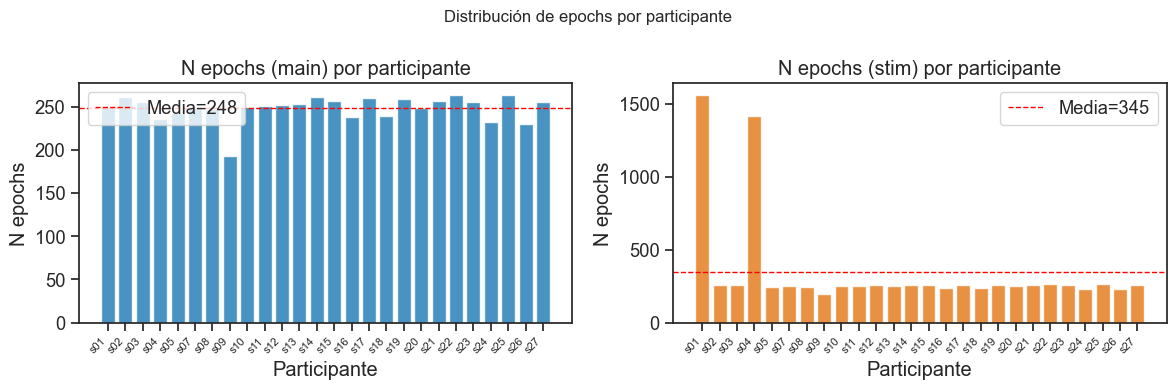


Resumen epochs principales:
  Media: 248
  Mín  : 193 (s09)
  Máx  : 264 (s22)


In [9]:
# Cuántos epochs hay por participante y por condición
n_epochs_per_subj = [len(e) for e in all_epochs]
n_stim_per_subj   = [len(e) for e in all_stim_epochs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Epochs principales por participante
axes[0].bar(subjs_loaded, n_epochs_per_subj, color='#2980b9', alpha=0.85)
axes[0].axhline(np.mean(n_epochs_per_subj), color='red', linestyle='--',
                linewidth=1, label=f'Media={np.mean(n_epochs_per_subj):.0f}')
axes[0].set_title('N epochs (main) por participante')
axes[0].set_xlabel('Participante')
axes[0].set_ylabel('N epochs')
axes[0].set_xticklabels(subjs_loaded, rotation=45, ha='right', fontsize=8)
axes[0].legend()

# Epochs de estímulo por participante
axes[1].bar(subjs_stim_loaded, n_stim_per_subj, color='#e67e22', alpha=0.85)
axes[1].axhline(np.mean(n_stim_per_subj), color='red', linestyle='--',
                linewidth=1, label=f'Media={np.mean(n_stim_per_subj):.0f}')
axes[1].set_title('N epochs (stim) por participante')
axes[1].set_xlabel('Participante')
axes[1].set_ylabel('N epochs')
axes[1].set_xticklabels(subjs_stim_loaded, rotation=45, ha='right', fontsize=8)
axes[1].legend()

plt.suptitle('Distribución de epochs por participante', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nResumen epochs principales:')
print(f'  Media: {np.mean(n_epochs_per_subj):.0f}')
print(f'  Mín  : {np.min(n_epochs_per_subj)} ({subjs_loaded[np.argmin(n_epochs_per_subj)]})')
print(f'  Máx  : {np.max(n_epochs_per_subj)} ({subjs_loaded[np.argmax(n_epochs_per_subj)]})')

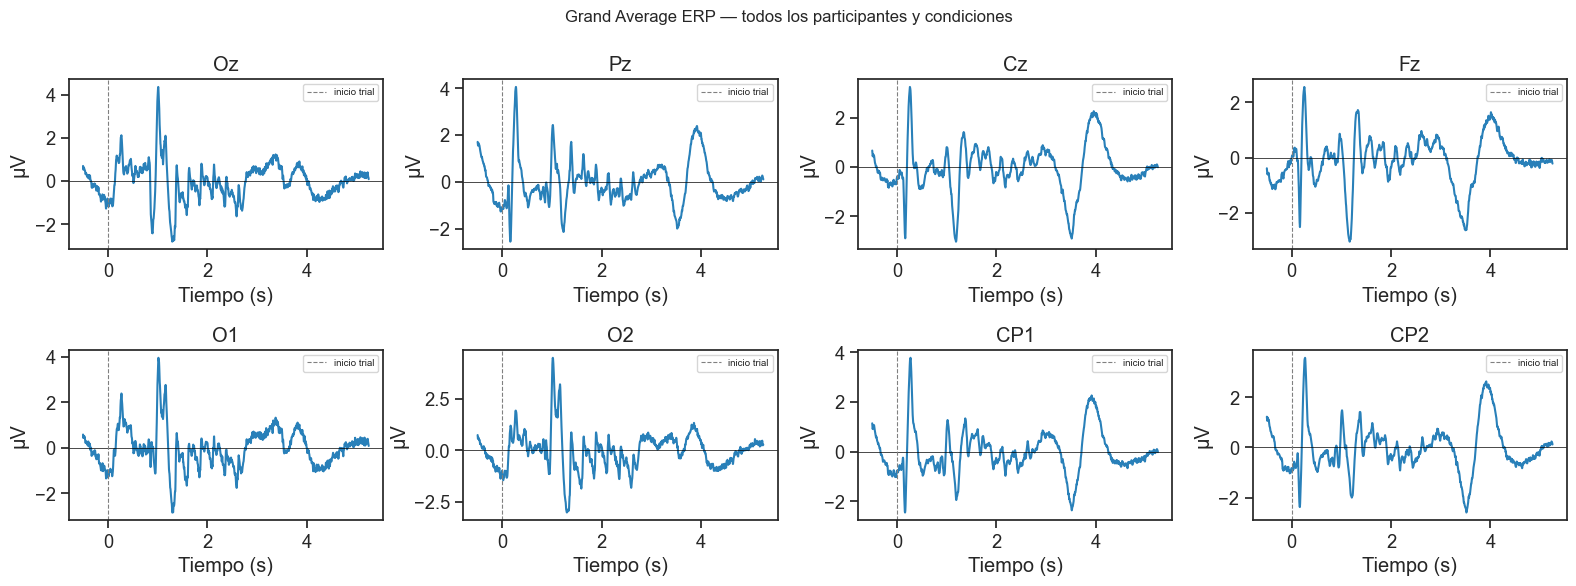

In [10]:
# Los canales más relevantes para decisión perceptual visual son los occipito-parietales
# Oz, O1, O2 → procesamiento visual primario
# Pz, CP1, CP2 → integración sensoriomotora, P300 (atención y decisión)
# Cz, Fz → componentes frontales relacionados con decisión

channels_of_interest = ['Oz', 'Pz', 'Cz', 'Fz', 'O1', 'O2', 'CP1', 'CP2']

# Calculamos el Grand Average (media de todos los participantes)
# grand_average combina los evoked de cada participante
grand_avg = mne.grand_average([epo.average() for epo in all_epochs])

# Visualizamos el ERP global en los canales de interés
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, ch in enumerate(channels_of_interest):
    ch_idx = grand_avg.ch_names.index(ch)
    times = grand_avg.times
    data  = grand_avg.data[ch_idx] * 1e6  # convertimos a microvoltios

    axes[i].plot(times, data, color='#2980b9', linewidth=1.5)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].axvline(0, color='gray', linewidth=0.8, linestyle='--',
                    label='inicio trial')
    axes[i].set_title(ch)
    axes[i].set_xlabel('Tiempo (s)')
    axes[i].set_ylabel('\u03bcV')
    axes[i].legend(fontsize=7)

plt.suptitle('Grand Average ERP — todos los participantes y condiciones',
             fontsize=12)
plt.tight_layout()
plt.show()

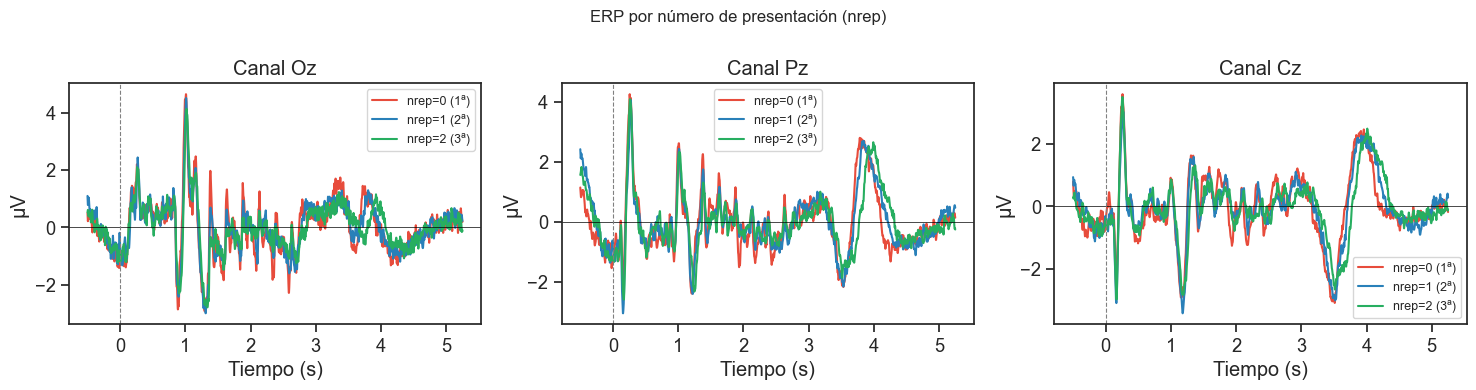

In [11]:
# ¿La señal EEG cambia con las repeticiones?
# Si los participantes integran información acumulada (como vimos conductualmente),
# esperamos diferencias en la amplitud o latencia de los componentes

colors_nrep = {0: '#e74c3c', 1: '#2980b9', 2: '#27ae60'}
labels_nrep = {0: 'nrep=0 (1ª)', 1: 'nrep=1 (2ª)', 2: 'nrep=2 (3ª)'}

# Calculamos evoked por nrep para cada participante y luego grand average
evokeds_nrep = {0: [], 1: [], 2: []}

for epo in all_epochs:
    for nrep_val in [0, 1, 2]:
        mask = epo.metadata['nrep'] == nrep_val
        if mask.sum() > 5:
            evokeds_nrep[nrep_val].append(epo[mask].average())

grand_avg_nrep = {
    nrep_val: mne.grand_average(evokeds_nrep[nrep_val])
    for nrep_val in [0, 1, 2]
    if len(evokeds_nrep[nrep_val]) > 0
}

# Plot en canales clave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ch in zip(axes, ['Oz', 'Pz', 'Cz']):
    ch_idx = grand_avg_nrep[0].ch_names.index(ch)
    for nrep_val in [0, 1, 2]:
        data = grand_avg_nrep[nrep_val].data[ch_idx] * 1e6
        times = grand_avg_nrep[nrep_val].times
        ax.plot(times, data, color=colors_nrep[nrep_val],
                linewidth=1.5, label=labels_nrep[nrep_val])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'Canal {ch}')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('\u03bcV')
    ax.legend(fontsize=9)

plt.suptitle('ERP por número de presentación (nrep)', fontsize=12)
plt.tight_layout()
plt.show()

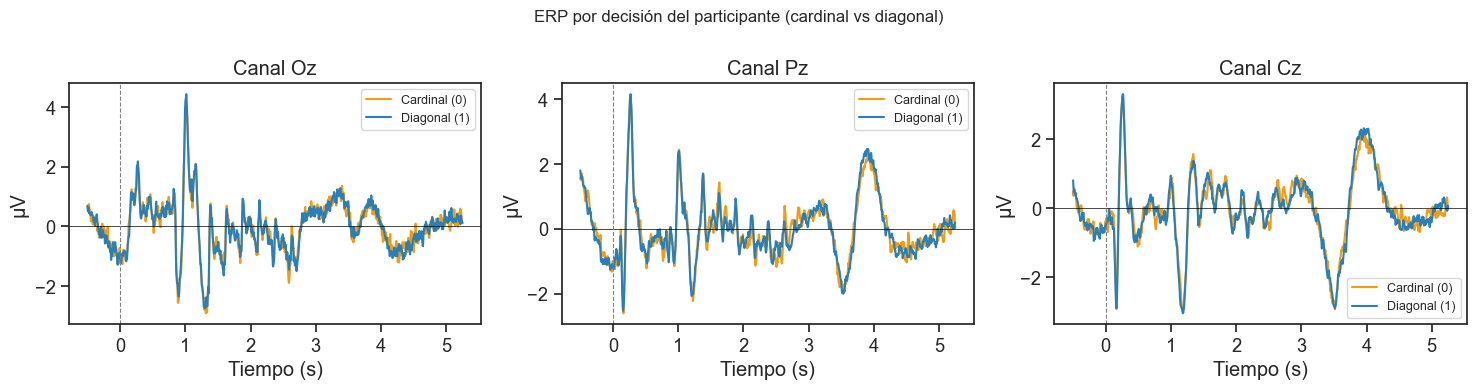

In [12]:
# ¿La señal EEG difiere según la decisión tomada?
# Si hay diferencias, el EEG codifica la categoría percibida

colors_deci = {0: '#f39c12', 1: '#2980b9'}
labels_deci = {0: 'Cardinal (0)', 1: 'Diagonal (1)'}

evokeds_deci = {0: [], 1: []}

for epo in all_epochs:
    for deci_val in [0, 1]:
        mask = epo.metadata['deci'] == deci_val
        if mask.sum() > 5:
            evokeds_deci[deci_val].append(epo[mask].average())

grand_avg_deci = {
    deci_val: mne.grand_average(evokeds_deci[deci_val])
    for deci_val in [0, 1]
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ch in zip(axes, ['Oz', 'Pz', 'Cz']):
    ch_idx = grand_avg_deci[0].ch_names.index(ch)
    for deci_val in [0, 1]:
        data = grand_avg_deci[deci_val].data[ch_idx] * 1e6
        times = grand_avg_deci[deci_val].times
        ax.plot(times, data, color=colors_deci[deci_val],
                linewidth=1.5, label=labels_deci[deci_val])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'Canal {ch}')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('\u03bcV')
    ax.legend(fontsize=9)

plt.suptitle('ERP por decisión del participante (cardinal vs diagonal)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# Verificamos qué columnas tiene cada participante en all_stim_epochs
print('Columnas de metadata en mainstim_epo por participante:\n')
for i, (epo, subj) in enumerate(zip(all_stim_epochs, subjs_stim_loaded)):
    cols = list(epo.metadata.columns)
    has_cong = 'cong_deci' in cols
    print(f'{subj}: cong_deci={has_cong} | N epochs={len(epo)} | cols={cols}')

Columnas de metadata en mainstim_epo por participante:

s01: cong_deci=True | N epochs=1563 | cols=['subj', 'trial_type', 'nblock', 'ntrial', 'nrep', 'stim_cond', 'cond-1', 'cong_deci', 'cong_stim', 'cond', 'deci-2', 'deci-1', 'deci', 'corr-1', 'correct', 'confi', 'conf_lvl', 'correct-1', 'RT', 'stim', 'dv', 'orient', 'ov']
s02: cong_deci=False | N epochs=261 | cols=['subj', 'nblock', 'ntrial', 'nrep', 'trial_type', 'cond-1', 'cond', 'rDV', 'DV', 'resp', 'deci-2', 'deci-1', 'deci', 'corr-1', 'r_map', 'correct', 'confi', 'RT', 'd1', 'conf_lvl', 'correct-1', 'd2', 'd3', 'd4', 'd5', 'd6', 'o1', 'o2', 'o3', 'o4', 'o5', 'o6', 'confi-1', 'conf_lvl-1']
s03: cong_deci=False | N epochs=256 | cols=['subj', 'nblock', 'ntrial', 'nrep', 'trial_type', 'cond-1', 'cond', 'rDV', 'DV', 'resp', 'deci-2', 'deci-1', 'deci', 'corr-1', 'r_map', 'correct', 'confi', 'RT', 'd1', 'conf_lvl', 'correct-1', 'd2', 'd3', 'd4', 'd5', 'd6', 'o1', 'o2', 'o3', 'o4', 'o5', 'o6', 'confi-1', 'conf_lvl-1']
s04: cong_deci=Tru

Participantes con datos congruentes  : 26
Participantes con datos incongruentes: 26


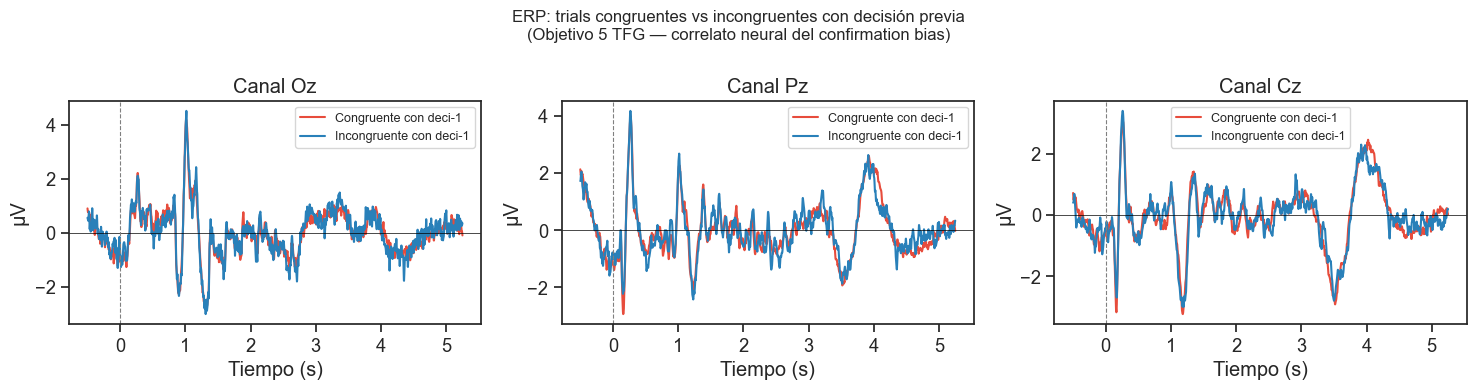

In [15]:
# Como la mayoría de participantes no tienen cong_deci en mainstim_epo,
# calculamos la congruencia directamente desde main_epo:
# Un trial es congruente si la condición actual (cond) coincide con
# la decisión previa (deci-1). Solo tiene sentido para nrep > 0.

colors_cong = {'C': '#e74c3c', 'I': '#2980b9'}
labels_cong = {'C': 'Congruente con deci-1', 'I': 'Incongruente con deci-1'}

evokeds_cong = {'C': [], 'I': []}

for epo in all_epochs:
    # Solo nrep > 0: necesitamos una decisión previa del mismo trial
    epo_sub = epo[epo.metadata['nrep'] > 0].copy()

    # Calculamos congruencia: cond == deci-1
    # cond=0 cardinal, cond=1 diagonal
    # deci-1=0 cardinal, deci-1=1 diagonal
    meta = epo_sub.metadata.copy()
    meta['cong'] = (meta['cond'] == meta['deci-1']).map(
        {True: 'C', False: 'I'}
    )
    epo_sub.metadata = meta

    for cong_val in ['C', 'I']:
        mask = epo_sub.metadata['cong'] == cong_val
        if mask.sum() > 5:
            evokeds_cong[cong_val].append(epo_sub[mask].average())

print(f'Participantes con datos congruentes  : {len(evokeds_cong["C"])}')
print(f'Participantes con datos incongruentes: {len(evokeds_cong["I"])}')

grand_avg_cong = {
    cong_val: mne.grand_average(evokeds_cong[cong_val])
    for cong_val in ['C', 'I']
}

# Plot ERP congruente vs incongruente
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ch in zip(axes, ['Oz', 'Pz', 'Cz']):
    ch_idx = grand_avg_cong['C'].ch_names.index(ch)
    for cong_val in ['C', 'I']:
        data  = grand_avg_cong[cong_val].data[ch_idx] * 1e6
        times = grand_avg_cong[cong_val].times
        ax.plot(times, data, color=colors_cong[cong_val],
                linewidth=1.5, label=labels_cong[cong_val])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'Canal {ch}')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('\u03bcV')
    ax.legend(fontsize=9)

plt.suptitle('ERP: trials congruentes vs incongruentes con decisión previa\n'
             '(Objetivo 5 TFG — correlato neural del confirmation bias)',
             fontsize=12)
plt.tight_layout()
plt.show()

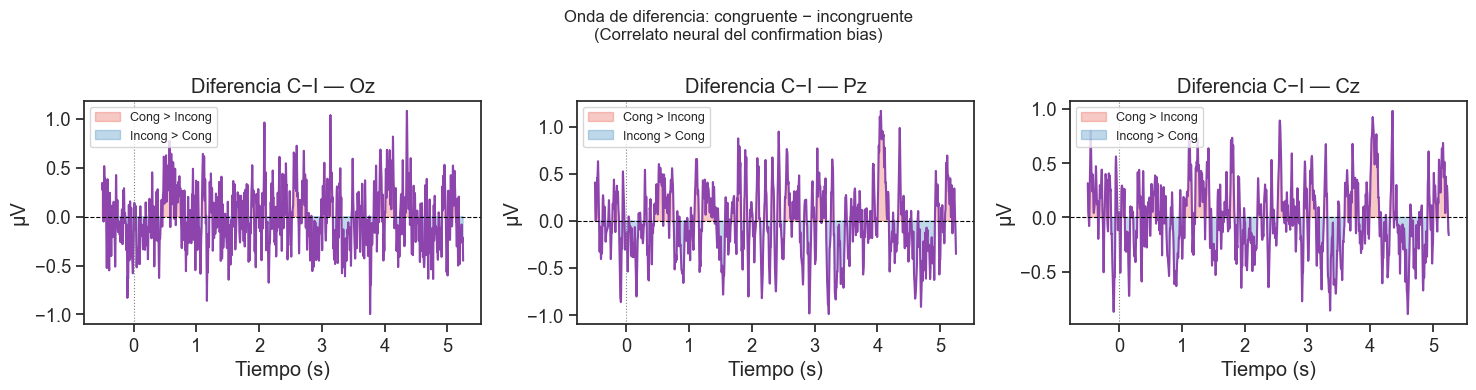

Amplitud media de la diferencia C−I por ventana temporal:

Canal Oz:
  Early (0.0-0.5s): -0.0910 µV
  Middle (0.5-2.0s): 0.0270 µV
  Late (2.0-4.0s): -0.0117 µV

Canal Pz:
  Early (0.0-0.5s): -0.1221 µV
  Middle (0.5-2.0s): 0.0296 µV
  Late (2.0-4.0s): -0.0310 µV

Canal Cz:
  Early (0.0-0.5s): -0.0636 µV
  Middle (0.5-2.0s): 0.0367 µV
  Late (2.0-4.0s): -0.0322 µV



In [16]:
# La onda de diferencia (congruente - incongruente) aísla el efecto puro
# del confirmation bias en la señal EEG.
# Una diferencia significativa positiva o negativa indica que el cerebro
# procesa de forma distinta los estímulos según su relación con la decisión previa
# La onda de diferencia aísla el efecto puro del confirmation bias
# en la señal EEG. Si hay diferencia, el cerebro procesa distinto
# los trials congruentes vs incongruentes con la decisión previa.

diff_data = (grand_avg_cong['C'].data - grand_avg_cong['I'].data) * 1e6
times = grand_avg_cong['C'].times

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, ch in zip(axes, ['Oz', 'Pz', 'Cz']):
    ch_idx = grand_avg_cong['C'].ch_names.index(ch)
    ax.plot(times, diff_data[ch_idx], color='#8e44ad', linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.fill_between(times, diff_data[ch_idx], 0,
                    where=diff_data[ch_idx] > 0,
                    alpha=0.3, color='#e74c3c', label='Cong > Incong')
    ax.fill_between(times, diff_data[ch_idx], 0,
                    where=diff_data[ch_idx] < 0,
                    alpha=0.3, color='#2980b9', label='Incong > Cong')
    ax.set_title(f'Diferencia C−I — {ch}')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('\u03bcV')
    ax.legend(fontsize=9)

plt.suptitle('Onda de diferencia: congruente − incongruente\n'
             '(Correlato neural del confirmation bias)', fontsize=12)
plt.tight_layout()
plt.show()

# Amplitud media de la diferencia en ventanas temporales clave
print('Amplitud media de la diferencia C−I por ventana temporal:\n')
windows = {
    'Early (0.0-0.5s)'  : (0.0, 0.5),
    'Middle (0.5-2.0s)' : (0.5, 2.0),
    'Late (2.0-4.0s)'   : (2.0, 4.0),
}
for ch in ['Oz', 'Pz', 'Cz']:
    ch_idx = grand_avg_cong['C'].ch_names.index(ch)
    print(f'Canal {ch}:')
    for win_name, (t1, t2) in windows.items():
        mask_t = (times >= t1) & (times <= t2)
        mean_diff = diff_data[ch_idx][mask_t].mean()
        print(f'  {win_name}: {mean_diff:.4f} µV')
    print()

In [17]:
# Para el decoding necesitamos:
# X: matriz de señal EEG (n_epochs × n_canales × n_tiempos)
# y: vector de etiquetas (n_epochs,) → deci = 0 o 1

# Eliminamos el canal 'Eye' (artefacto ocular, no señal cerebral)
# y 'LM', 'RM' (electrodos de referencia mastoides)
channels_to_drop = ['Eye', 'LM', 'RM']

# Recortamos la ventana temporal para reducir el coste computacional
# Nos quedamos con 0 a 4 segundos (donde están los 6 estímulos)
tmin_dec, tmax_dec = 0.0, 4.0

print('Preparando datos para decoding...')
print(f'Ventana temporal: {tmin_dec} a {tmax_dec} s')
print(f'Canales eliminados: {channels_to_drop}')

# Preparamos X e y por participante
X_list = []
y_list = []
subjs_dec = []

for epo, subj in zip(all_epochs, subjs_loaded):
    # Copiar y recortar
    epo_dec = epo.copy()

    # Eliminar canales no cerebrales si existen
    chs_drop = [c for c in channels_to_drop if c in epo_dec.ch_names]
    if chs_drop:
        epo_dec.drop_channels(chs_drop)

    # Recortar ventana temporal
    epo_dec.crop(tmin=tmin_dec, tmax=tmax_dec)

    # Obtener X e y
    X = epo_dec.get_data()          # shape: (n_epochs, n_canales, n_tiempos)
    y = epo_dec.metadata['deci'].values.astype(int)

    # Verificar que no hay NaN
    if np.isnan(X).any():
        print(f'  {subj}: contiene NaN, saltando.')
        continue

    X_list.append(X)
    y_list.append(y)
    subjs_dec.append(subj)

print(f'\nParticipantes válidos: {len(subjs_dec)}')
print(f'Shape X ejemplo (s01): {X_list[0].shape}')
print(f'  → {X_list[0].shape[0]} epochs × '
      f'{X_list[0].shape[1]} canales × '
      f'{X_list[0].shape[2]} puntos temporales')
print(f'Distribución deci (s01): '
      f'cardinal={( y_list[0]==0).sum()}, '
      f'diagonal={(y_list[0]==1).sum()}')

Preparando datos para decoding...
Ventana temporal: 0.0 a 4.0 s
Canales eliminados: ['Eye', 'LM', 'RM']

Participantes válidos: 26
Shape X ejemplo (s01): (250, 29, 2001)
  → 250 epochs × 29 canales × 2001 puntos temporales
Distribución deci (s01): cardinal=81, diagonal=169


In [18]:
# Para cada punto temporal t, entrenamos un clasificador con los
# 32 canales como features y evaluamos con validación cruzada.
# Usamos LDA (Linear Discriminant Analysis) porque es rápido,
# robusto con pocos datos y estándar en neurociencia computacional.

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis())
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Obtenemos los tiempos del primer participante como referencia
times_dec = all_epochs[0].copy().crop(tmin_dec, tmax_dec).times
n_times = len(times_dec)

print(f'N puntos temporales: {n_times}')
print(f'Esto puede tardar varios minutos...')

# Calculamos accuracy por tiempo y por participante
scores_per_subj = np.zeros((len(X_list), n_times))

for i, (X, y, subj) in enumerate(zip(X_list, y_list, subjs_dec)):
    for t in range(n_times):
        X_t = X[:, :, t]  # shape: (n_epochs, n_canales)
        scores = cross_val_score(clf, X_t, y,
                                 cv=skf, scoring='roc_auc', n_jobs=-1)
        scores_per_subj[i, t] = scores.mean()

    print(f'  {subj} completado. '
          f'AUC máx={scores_per_subj[i].max():.3f} '
          f'en t={times_dec[scores_per_subj[i].argmax()]:.2f}s')

print('\nDecoding completado.')

N puntos temporales: 2001
Esto puede tardar varios minutos...
  s01 completado. AUC máx=0.662 en t=2.74s
  s02 completado. AUC máx=0.671 en t=3.13s
  s03 completado. AUC máx=0.667 en t=3.57s
  s04 completado. AUC máx=0.639 en t=0.94s
  s05 completado. AUC máx=0.691 en t=1.14s
  s07 completado. AUC máx=0.636 en t=1.17s
  s08 completado. AUC máx=0.667 en t=3.52s
  s09 completado. AUC máx=0.736 en t=1.32s
  s10 completado. AUC máx=0.660 en t=2.76s
  s11 completado. AUC máx=0.654 en t=2.99s
  s12 completado. AUC máx=0.683 en t=1.93s
  s13 completado. AUC máx=0.647 en t=1.06s
  s14 completado. AUC máx=0.664 en t=0.98s
  s15 completado. AUC máx=0.668 en t=3.06s
  s16 completado. AUC máx=0.635 en t=0.68s
  s17 completado. AUC máx=0.666 en t=1.96s
  s18 completado. AUC máx=0.655 en t=0.06s
  s19 completado. AUC máx=0.648 en t=3.27s
  s20 completado. AUC máx=0.669 en t=2.69s
  s21 completado. AUC máx=0.698 en t=2.52s
  s22 completado. AUC máx=0.637 en t=0.71s
  s23 completado. AUC máx=0.638 en 

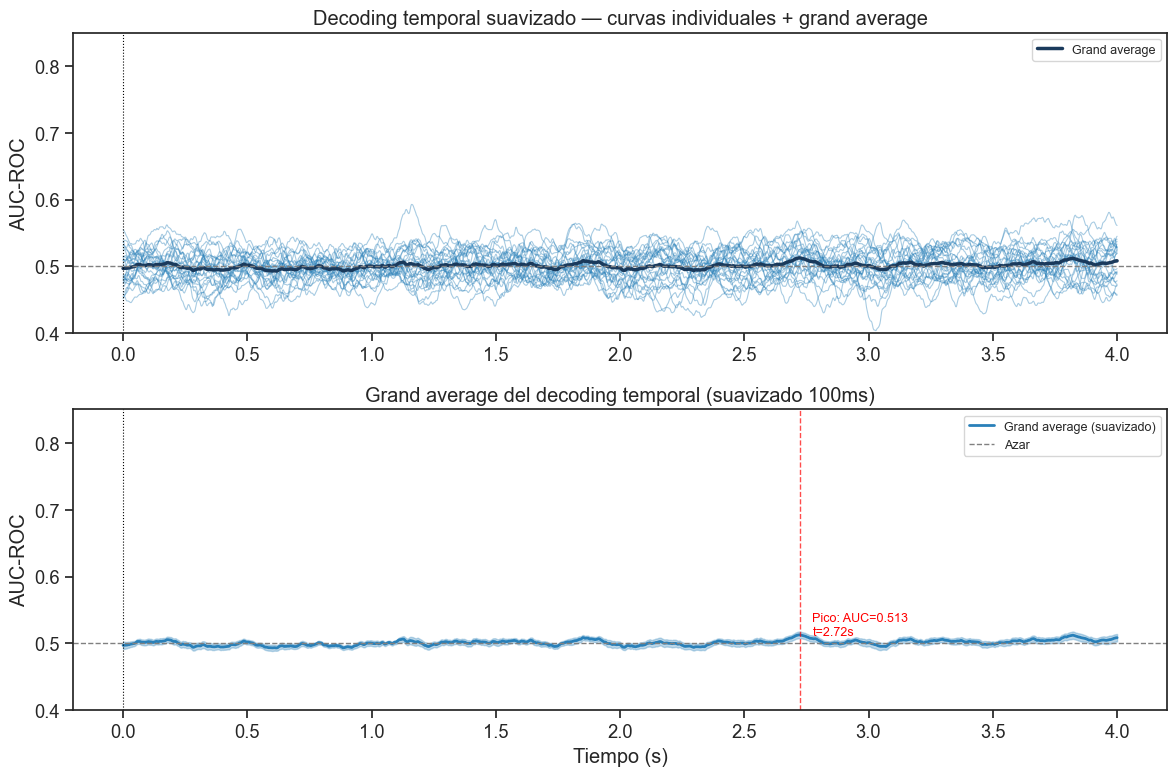

AUC máximo (suavizado): 0.513 en t=2.72s
AUC medio global      : 0.501

AUC máximo por participante (sin suavizar):
  s01: AUC=0.662 en t=2.74s
  s02: AUC=0.671 en t=3.13s
  s03: AUC=0.667 en t=3.57s
  s04: AUC=0.639 en t=0.94s
  s05: AUC=0.691 en t=1.14s
  s07: AUC=0.636 en t=1.17s
  s08: AUC=0.667 en t=3.52s
  s09: AUC=0.736 en t=1.32s
  s10: AUC=0.660 en t=2.76s
  s11: AUC=0.654 en t=2.99s
  s12: AUC=0.683 en t=1.93s
  s13: AUC=0.647 en t=1.06s
  s14: AUC=0.664 en t=0.98s
  s15: AUC=0.668 en t=3.06s
  s16: AUC=0.635 en t=0.68s
  s17: AUC=0.666 en t=1.96s
  s18: AUC=0.655 en t=0.06s
  s19: AUC=0.648 en t=3.27s
  s20: AUC=0.669 en t=2.69s
  s21: AUC=0.698 en t=2.52s
  s22: AUC=0.637 en t=0.71s
  s23: AUC=0.638 en t=3.70s
  s24: AUC=0.688 en t=0.32s
  s25: AUC=0.714 en t=3.81s
  s26: AUC=0.649 en t=3.13s
  s27: AUC=0.650 en t=0.55s

Media de AUC máximos individuales: 0.665
Std  de AUC máximos individuales: 0.024


In [21]:
# Aplicamos suavizado temporal (ventana deslizante) antes de promediar
# Esto agrupa puntos temporales cercanos y hace los picos más robustos

from scipy.ndimage import uniform_filter1d

# Parámetro: ventana de suavizado en puntos (100ms = 50 puntos a 500Hz)
smooth_window = 50

scores_smoothed = np.array([
    uniform_filter1d(s, size=smooth_window)
    for s in scores_per_subj
])

grand_avg_smooth = scores_smoothed.mean(axis=0)
sem_smooth = scores_smoothed.std(axis=0) / np.sqrt(len(scores_smoothed))

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Panel superior: curvas individuales suavizadas
for i, subj in enumerate(subjs_dec):
    axes[0].plot(times_dec, scores_smoothed[i],
                 alpha=0.4, linewidth=0.8, color='#2980b9')
axes[0].plot(times_dec, grand_avg_smooth,
             color='#1a3a5c', linewidth=2.5, label='Grand average')
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle=':')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Decoding temporal suavizado — curvas individuales + grand average')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.4, 0.85)

# Panel inferior: grand average con banda de error
axes[1].fill_between(times_dec,
                     grand_avg_smooth - sem_smooth,
                     grand_avg_smooth + sem_smooth,
                     alpha=0.3, color='#2980b9')
axes[1].plot(times_dec, grand_avg_smooth,
             color='#2980b9', linewidth=2, label='Grand average (suavizado)')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Azar')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle=':')

# Marcamos el pico
peak_t_s = times_dec[grand_avg_smooth.argmax()]
peak_auc_s = grand_avg_smooth.max()
axes[1].axvline(peak_t_s, color='red', linewidth=1,
                linestyle='--', alpha=0.7)
axes[1].text(peak_t_s + 0.05, peak_auc_s,
             f'Pico: AUC={peak_auc_s:.3f}\nt={peak_t_s:.2f}s',
             fontsize=9, color='red')

axes[1].set_xlabel('Tiempo (s)')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Grand average del decoding temporal (suavizado 100ms)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.4, 0.85)

plt.tight_layout()
plt.show()

print(f'AUC máximo (suavizado): {peak_auc_s:.3f} en t={peak_t_s:.2f}s')
print(f'AUC medio global      : {grand_avg_smooth.mean():.3f}')
print(f'\nAUC máximo por participante (sin suavizar):')
for i, subj in enumerate(subjs_dec):
    peak = scores_per_subj[i].max()
    peak_t_i = times_dec[scores_per_subj[i].argmax()]
    print(f'  {subj}: AUC={peak:.3f} en t={peak_t_i:.2f}s')

print(f'\nMedia de AUC máximos individuales: '
      f'{np.mean([scores_per_subj[i].max() for i in range(len(subjs_dec))]):.3f}')
print(f'Std  de AUC máximos individuales: '
      f'{np.std([scores_per_subj[i].max() for i in range(len(subjs_dec))]):.3f}')

nrep=0: AUC máx=0.561 en t=1.59s
nrep=1: AUC máx=0.556 en t=3.87s
nrep=2: AUC máx=0.560 en t=3.16s


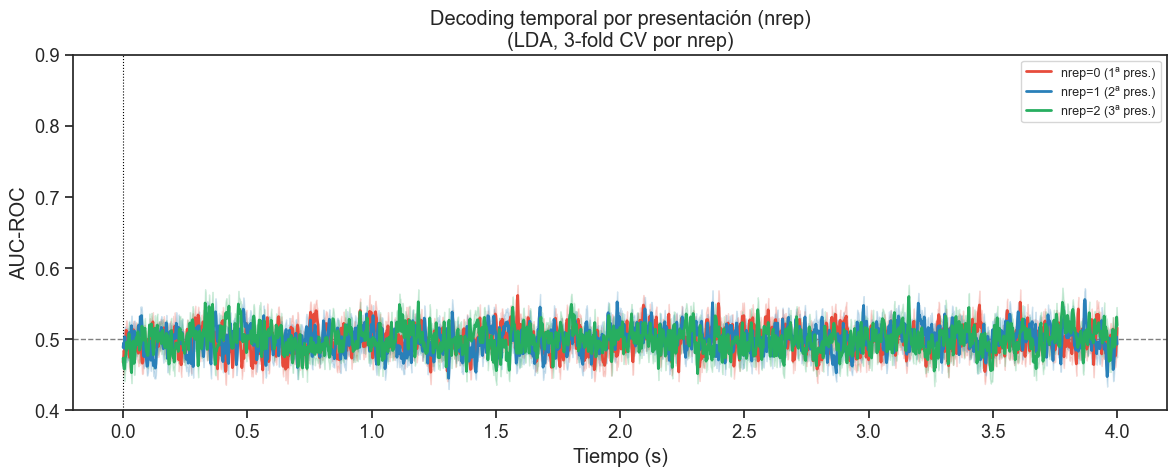

In [20]:
# ¿El EEG predice mejor la decisión en nrep=1 y 2 (donde hay historia)?
# Si el CB afecta a la señal EEG, esperamos mejor decoding cuando
# la decisión previa es más informativa

scores_nrep = {0: [], 1: [], 2: []}

for X, y_full, epo, subj in zip(X_list, y_list,
                                  all_epochs, subjs_dec):
    # Ventana temporal ya recortada en X_list
    epo_dec = epo.copy()
    chs_drop = [c for c in channels_to_drop if c in epo_dec.ch_names]
    if chs_drop:
        epo_dec.drop_channels(chs_drop)
    epo_dec.crop(tmin=tmin_dec, tmax=tmax_dec)

    for nrep_val in [0, 1, 2]:
        mask = epo_dec.metadata['nrep'].values == nrep_val
        if mask.sum() < 20:
            continue

        X_sub = X[mask]
        y_sub = y_full[mask]

        scores_t = np.zeros(n_times)
        for t in range(n_times):
            X_t = X_sub[:, :, t]
            try:
                sc = cross_val_score(clf, X_t, y_sub,
                                     cv=StratifiedKFold(n_splits=3,
                                                        shuffle=True,
                                                        random_state=42),
                                     scoring='roc_auc', n_jobs=-1)
                scores_t[t] = sc.mean()
            except Exception:
                scores_t[t] = 0.5

        scores_nrep[nrep_val].append(scores_t)

# Grand average por nrep
colors_nrep = {0: '#e74c3c', 1: '#2980b9', 2: '#27ae60'}
labels_nrep = {0: 'nrep=0 (1ª pres.)', 1: 'nrep=1 (2ª pres.)',
               2: 'nrep=2 (3ª pres.)'}

fig, ax = plt.subplots(figsize=(12, 5))
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linewidth=0.8, linestyle=':')

for nrep_val in [0, 1, 2]:
    if len(scores_nrep[nrep_val]) > 0:
        ga = np.mean(scores_nrep[nrep_val], axis=0)
        sem = np.std(scores_nrep[nrep_val], axis=0) / \
              np.sqrt(len(scores_nrep[nrep_val]))
        ax.plot(times_dec, ga, color=colors_nrep[nrep_val],
                linewidth=2, label=labels_nrep[nrep_val])
        ax.fill_between(times_dec, ga - sem, ga + sem,
                        alpha=0.2, color=colors_nrep[nrep_val])
        print(f'nrep={nrep_val}: AUC máx={ga.max():.3f} '
              f'en t={times_dec[ga.argmax()]:.2f}s')

ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('AUC-ROC')
ax.set_title('Decoding temporal por presentación (nrep)\n'
             '(LDA, 3-fold CV por nrep)')
ax.legend(fontsize=9)
ax.set_ylim(0.4, 0.9)
plt.tight_layout()
plt.show()

In [22]:
# Cargamos mainresp_epo.fif: alineado a la respuesta (-1.5 a +0.75s)
# Aquí la señal decisional debería estar concentrada justo antes de t=0

all_resp_epochs = []
subjs_resp_loaded = []

for subj in subjs_list:
    fif_path = os.path.join(eeg_path, subj, 'mainresp_epo.fif')
    if not os.path.exists(fif_path):
        continue
    try:
        epo = mne.read_epochs(fif_path, preload=True, verbose=False)
        all_resp_epochs.append(epo)
        subjs_resp_loaded.append(subj)
        print(f'  {subj}: {len(epo)} epochs cargados.')
    except Exception as e:
        print(f'  {subj}: ERROR — {e}')

print(f'\nTotal: {len(subjs_resp_loaded)} participantes, '
      f'{sum(len(e) for e in all_resp_epochs)} epochs')
print(f'Ventana temporal: {all_resp_epochs[0].tmin:.2f} '
      f'a {all_resp_epochs[0].tmax:.2f} s')

  s01: 239 epochs cargados.
  s03: 258 epochs cargados.
  s04: 249 epochs cargados.
  s05: 238 epochs cargados.
  s07: 245 epochs cargados.
  s08: 245 epochs cargados.
  s09: 186 epochs cargados.
  s10: 259 epochs cargados.
  s11: 251 epochs cargados.
  s12: 260 epochs cargados.
  s13: 256 epochs cargados.
  s14: 260 epochs cargados.
  s15: 258 epochs cargados.
  s16: 258 epochs cargados.
  s17: 263 epochs cargados.
  s18: 252 epochs cargados.
  s19: 260 epochs cargados.
  s20: 245 epochs cargados.
  s21: 260 epochs cargados.
  s22: 261 epochs cargados.
  s23: 262 epochs cargados.
  s24: 259 epochs cargados.
  s25: 264 epochs cargados.
  s26: 246 epochs cargados.
  s27: 264 epochs cargados.

Total: 25 participantes, 6298 epochs
Ventana temporal: -1.50 a 0.75 s


In [23]:
# Decoding sobre mainresp_epo: ventana -1.5 a +0.75s
# En este caso t=0 es el momento exacto de la respuesta
# Esperamos que el AUC suba antes de t=0 (mientras el participante decide)

X_resp_list = []
y_resp_list = []

for epo, subj in zip(all_resp_epochs, subjs_resp_loaded):
    epo_dec = epo.copy()
    chs_drop = [c for c in channels_to_drop if c in epo_dec.ch_names]
    if chs_drop:
        epo_dec.drop_channels(chs_drop)

    X = epo_dec.get_data()
    y = epo_dec.metadata['deci'].values.astype(int)

    if np.isnan(X).any():
        continue

    X_resp_list.append(X)
    y_resp_list.append(y)

times_resp = all_resp_epochs[0].times
n_times_resp = len(times_resp)

print(f'N puntos temporales: {n_times_resp}')
print(f'Ejecutando decoding sobre mainresp_epo...')

scores_resp = np.zeros((len(X_resp_list), n_times_resp))

for i, (X, y, subj) in enumerate(zip(X_resp_list, y_resp_list,
                                       subjs_resp_loaded)):
    for t in range(n_times_resp):
        X_t = X[:, :, t]
        sc = cross_val_score(clf, X_t, y, cv=skf,
                             scoring='roc_auc', n_jobs=-1)
        scores_resp[i, t] = sc.mean()

    print(f'  {subj}: AUC máx={scores_resp[i].max():.3f} '
          f'en t={times_resp[scores_resp[i].argmax()]:.2f}s')

N puntos temporales: 1126
Ejecutando decoding sobre mainresp_epo...
  s01: AUC máx=0.658 en t=-1.42s
  s03: AUC máx=0.641 en t=-1.43s
  s04: AUC máx=0.660 en t=-0.06s
  s05: AUC máx=0.664 en t=-1.22s
  s07: AUC máx=0.634 en t=-0.18s
  s08: AUC máx=0.648 en t=-0.23s
  s09: AUC máx=0.707 en t=-0.03s
  s10: AUC máx=0.628 en t=-0.36s
  s11: AUC máx=0.650 en t=0.11s
  s12: AUC máx=0.668 en t=0.12s
  s13: AUC máx=0.646 en t=-0.57s
  s14: AUC máx=0.670 en t=-0.85s
  s15: AUC máx=0.641 en t=-0.80s
  s16: AUC máx=0.639 en t=-0.68s
  s17: AUC máx=0.648 en t=0.60s
  s18: AUC máx=0.650 en t=0.34s
  s19: AUC máx=0.669 en t=-0.47s
  s20: AUC máx=0.667 en t=0.20s
  s21: AUC máx=0.628 en t=0.34s
  s22: AUC máx=0.652 en t=-0.35s
  s23: AUC máx=0.646 en t=-1.17s
  s24: AUC máx=0.637 en t=-1.37s
  s25: AUC máx=0.646 en t=-1.02s
  s26: AUC máx=0.638 en t=-0.38s
  s27: AUC máx=0.637 en t=-0.56s


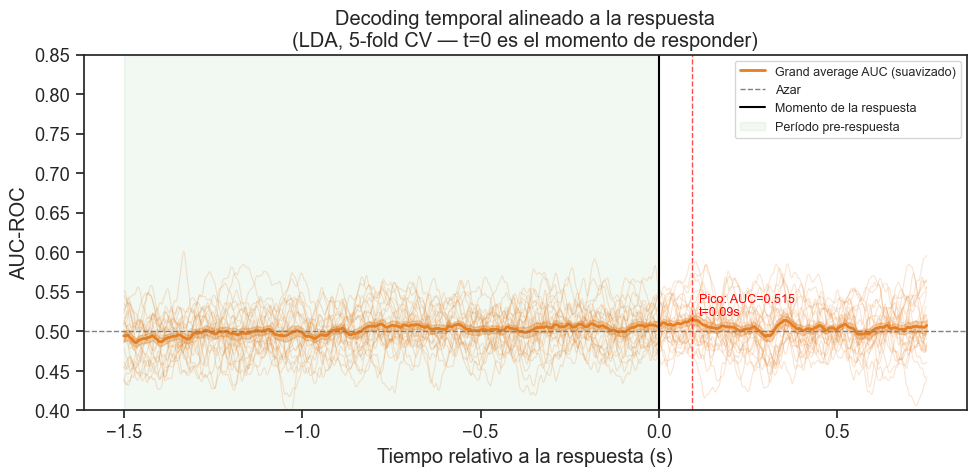


AUC máximo (grand avg suavizado): 0.515 en t=0.09s
Media AUC máximos individuales  : 0.651


In [24]:
# Visualización del decoding sobre respuesta
from scipy.ndimage import uniform_filter1d

scores_resp_smooth = np.array([
    uniform_filter1d(s, size=25)  # ventana 50ms (25 puntos a 500Hz)
    for s in scores_resp
])

grand_resp_smooth = scores_resp_smooth.mean(axis=0)
sem_resp = scores_resp_smooth.std(axis=0) / np.sqrt(len(scores_resp_smooth))

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(times_resp,
                grand_resp_smooth - sem_resp,
                grand_resp_smooth + sem_resp,
                alpha=0.3, color='#e67e22')
ax.plot(times_resp, grand_resp_smooth,
        color='#e67e22', linewidth=2,
        label='Grand average AUC (suavizado)')

for i in range(len(scores_resp_smooth)):
    ax.plot(times_resp, scores_resp_smooth[i],
            alpha=0.2, linewidth=0.8, color='#e67e22')

ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=1, label='Azar')
ax.axvline(0, color='black', linewidth=1.5,
           linestyle='-', label='Momento de la respuesta')
ax.axvspan(-1.5, 0, alpha=0.05, color='green',
           label='Período pre-respuesta')

peak_t = times_resp[grand_resp_smooth.argmax()]
peak_auc = grand_resp_smooth.max()
ax.axvline(peak_t, color='red', linewidth=1,
           linestyle='--', alpha=0.7)
ax.text(peak_t + 0.02, peak_auc + 0.005,
        f'Pico: AUC={peak_auc:.3f}\nt={peak_t:.2f}s',
        fontsize=9, color='red')

ax.set_xlabel('Tiempo relativo a la respuesta (s)')
ax.set_ylabel('AUC-ROC')
ax.set_title('Decoding temporal alineado a la respuesta\n'
             '(LDA, 5-fold CV — t=0 es el momento de responder)')
ax.legend(fontsize=9)
ax.set_ylim(0.4, 0.85)
plt.tight_layout()
plt.show()

print(f'\nAUC máximo (grand avg suavizado): {peak_auc:.3f} en t={peak_t:.2f}s')
print(f'Media AUC máximos individuales  : '
      f'{np.mean([scores_resp[i].max() for i in range(len(scores_resp))]):.3f}')

TEST: AUC máximos individuales vs azar (0.5)
N participantes     : 25
Media AUC máx       : 0.651
Std  AUC máx        : 0.017
Min  AUC máx        : 0.628
Max  AUC máx        : 0.707
t-statistic         : 44.060
p-valor             : 0.000000
Significativo (p<.05): SÍ ✓



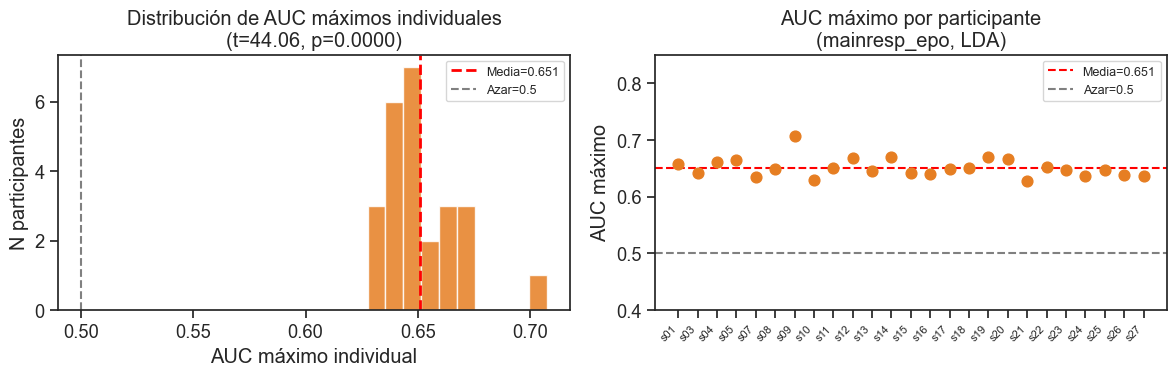

Participantes con AUC máx > 0.5: 25/25 (100%)

Comparación main_epo vs mainresp_epo:
  main_epo    : media AUC máx=0.665, t=34.031, p=0.000000
  mainresp_epo: media AUC máx=0.651, t=44.060, p=0.000000


In [25]:
# Test estadístico: ¿los AUC máximos individuales son > 0.5?
# Usamos un t-test de una muestra contra 0.5

auc_maximos = np.array([scores_resp[i].max()
                         for i in range(len(scores_resp))])

t_stat, p_val = stats.ttest_1samp(auc_maximos, 0.5)

print('=' * 50)
print('TEST: AUC máximos individuales vs azar (0.5)')
print('=' * 50)
print(f'N participantes     : {len(auc_maximos)}')
print(f'Media AUC máx       : {auc_maximos.mean():.3f}')
print(f'Std  AUC máx        : {auc_maximos.std():.3f}')
print(f'Min  AUC máx        : {auc_maximos.min():.3f}')
print(f'Max  AUC máx        : {auc_maximos.max():.3f}')
print(f't-statistic         : {t_stat:.3f}')
print(f'p-valor             : {p_val:.6f}')
print(f'Significativo (p<.05): {"SÍ ✓" if p_val < 0.05 else "No"}')
print()

# Visualización de la distribución de AUC máximos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(auc_maximos, bins=10, color='#e67e22',
             alpha=0.85, edgecolor='white')
axes[0].axvline(auc_maximos.mean(), color='red', linewidth=2,
                linestyle='--',
                label=f'Media={auc_maximos.mean():.3f}')
axes[0].axvline(0.5, color='gray', linewidth=1.5,
                linestyle='--', label='Azar=0.5')
axes[0].set_xlabel('AUC máximo individual')
axes[0].set_ylabel('N participantes')
axes[0].set_title('Distribución de AUC máximos individuales\n'
                  f'(t={t_stat:.2f}, p={p_val:.4f})')
axes[0].legend(fontsize=9)

# Scatter: AUC máximo por participante
axes[1].scatter(range(len(auc_maximos)), auc_maximos,
                color='#e67e22', s=60, zorder=3)
axes[1].axhline(auc_maximos.mean(), color='red', linewidth=1.5,
                linestyle='--',
                label=f'Media={auc_maximos.mean():.3f}')
axes[1].axhline(0.5, color='gray', linewidth=1.5,
                linestyle='--', label='Azar=0.5')
axes[1].set_xticks(range(len(auc_maximos)))
axes[1].set_xticklabels(subjs_resp_loaded, rotation=45,
                         ha='right', fontsize=8)
axes[1].set_ylabel('AUC máximo')
axes[1].set_title('AUC máximo por participante\n'
                  '(mainresp_epo, LDA)')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.4, 0.85)

plt.tight_layout()
plt.show()

# ¿Cuántos participantes superan el azar?
n_above = (auc_maximos > 0.5).sum()
print(f'Participantes con AUC máx > 0.5: {n_above}/{len(auc_maximos)} '
      f'({n_above/len(auc_maximos)*100:.0f}%)')

# También sobre main_epo para comparar
auc_maximos_main = np.array([scores_per_subj[i].max()
                              for i in range(len(scores_per_subj))])
t2, p2 = stats.ttest_1samp(auc_maximos_main, 0.5)
print(f'\nComparación main_epo vs mainresp_epo:')
print(f'  main_epo    : media AUC máx={auc_maximos_main.mean():.3f}, '
      f't={t2:.3f}, p={p2:.6f}')
print(f'  mainresp_epo: media AUC máx={auc_maximos.mean():.3f}, '
      f't={t_stat:.3f}, p={p_val:.6f}')

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_64364/559912256.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(subjs_resp_loaded,


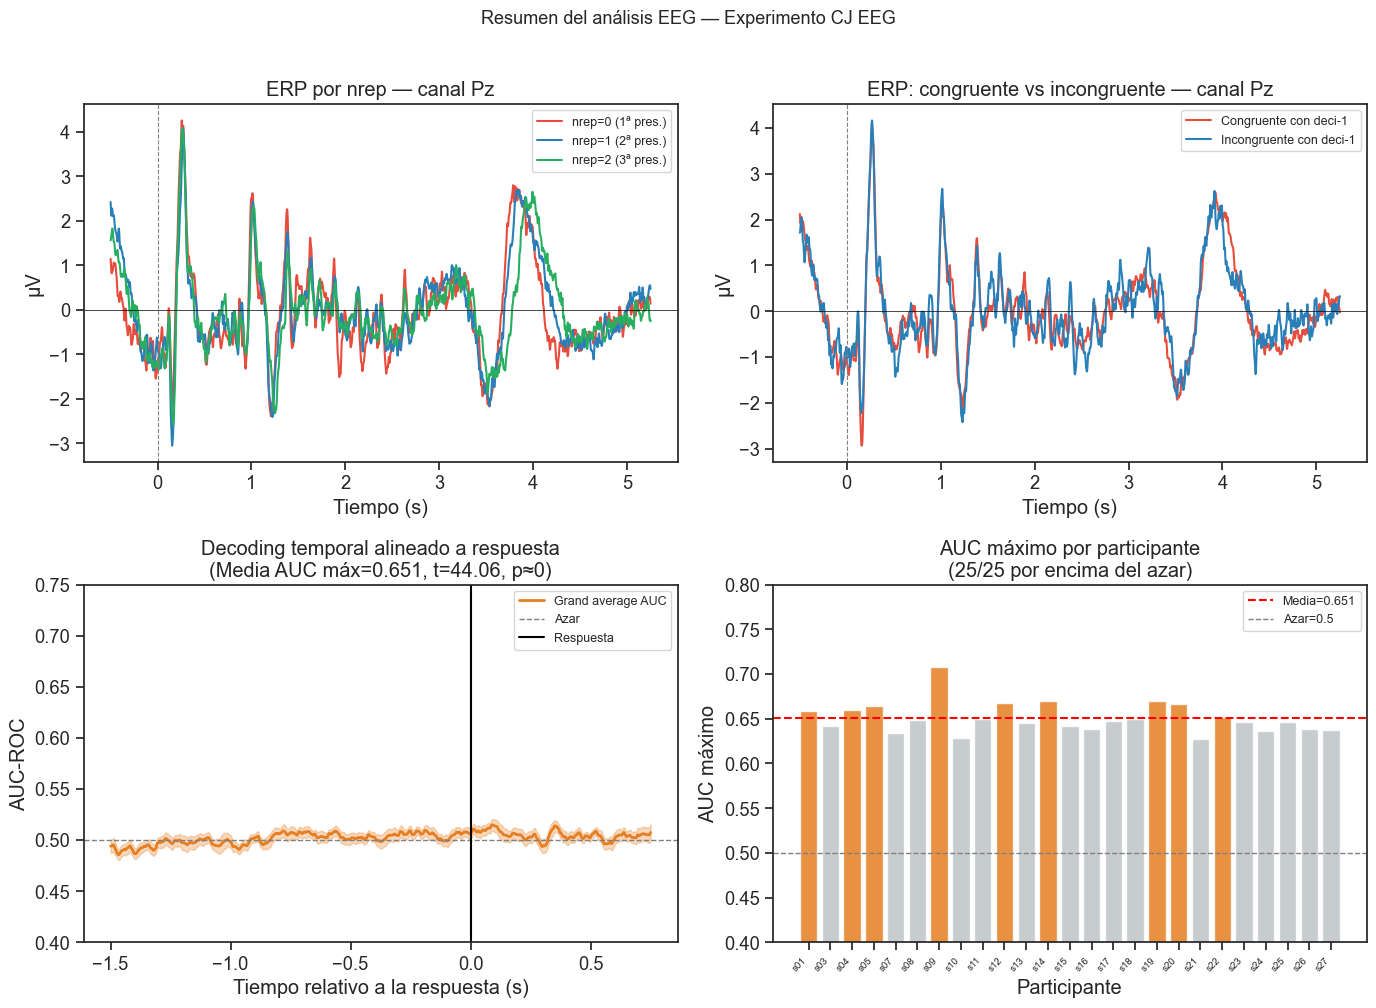

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 1. Grand average ERP por nrep (canal Pz) ─────────────────────────────────
ch = 'Pz'
ch_idx = grand_avg_nrep[0].ch_names.index(ch)
for nrep_val in [0, 1, 2]:
    data  = grand_avg_nrep[nrep_val].data[ch_idx] * 1e6
    times = grand_avg_nrep[nrep_val].times
    axes[0,0].plot(times, data, color=colors_nrep[nrep_val],
                   linewidth=1.5, label=labels_nrep[nrep_val])
axes[0,0].axhline(0, color='black', linewidth=0.5)
axes[0,0].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0,0].set_title(f'ERP por nrep — canal {ch}')
axes[0,0].set_xlabel('Tiempo (s)')
axes[0,0].set_ylabel('µV')
axes[0,0].legend(fontsize=9)

# ── 2. ERP congruente vs incongruente (canal Pz) ─────────────────────────────
ch_idx_pz = grand_avg_cong['C'].ch_names.index('Pz')
for cong_val in ['C', 'I']:
    data  = grand_avg_cong[cong_val].data[ch_idx_pz] * 1e6
    times = grand_avg_cong[cong_val].times
    axes[0,1].plot(times, data, color=colors_cong[cong_val],
                   linewidth=1.5, label=labels_cong[cong_val])
axes[0,1].axhline(0, color='black', linewidth=0.5)
axes[0,1].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0,1].set_title('ERP: congruente vs incongruente — canal Pz')
axes[0,1].set_xlabel('Tiempo (s)')
axes[0,1].set_ylabel('µV')
axes[0,1].legend(fontsize=9)

# ── 3. Decoding temporal (mainresp_epo suavizado) ────────────────────────────
axes[1,0].fill_between(times_resp,
                        grand_resp_smooth - sem_resp,
                        grand_resp_smooth + sem_resp,
                        alpha=0.3, color='#e67e22')
axes[1,0].plot(times_resp, grand_resp_smooth,
               color='#e67e22', linewidth=2, label='Grand average AUC')
axes[1,0].axhline(0.5, color='gray', linestyle='--',
                  linewidth=1, label='Azar')
axes[1,0].axvline(0, color='black', linewidth=1.5, linestyle='-',
                  label='Respuesta')
axes[1,0].set_xlabel('Tiempo relativo a la respuesta (s)')
axes[1,0].set_ylabel('AUC-ROC')
axes[1,0].set_title(f'Decoding temporal alineado a respuesta\n'
                    f'(Media AUC máx={auc_maximos.mean():.3f}, '
                    f't=44.06, p≈0)')
axes[1,0].legend(fontsize=9)
axes[1,0].set_ylim(0.4, 0.75)

# ── 4. AUC máximo por participante ───────────────────────────────────────────
colors_subj_eeg = ['#e67e22' if a >= auc_maximos.mean()
                   else '#bdc3c7' for a in auc_maximos]
axes[1,1].bar(subjs_resp_loaded, auc_maximos,
              color=colors_subj_eeg, alpha=0.85)
axes[1,1].axhline(auc_maximos.mean(), color='red', linewidth=1.5,
                  linestyle='--',
                  label=f'Media={auc_maximos.mean():.3f}')
axes[1,1].axhline(0.5, color='gray', linewidth=1,
                  linestyle='--', label='Azar=0.5')
axes[1,1].set_xlabel('Participante')
axes[1,1].set_ylabel('AUC máximo')
axes[1,1].set_title('AUC máximo por participante\n'
                    '(25/25 por encima del azar)')
axes[1,1].set_xticklabels(subjs_resp_loaded,
                           rotation=45, ha='right', fontsize=7)
axes[1,1].legend(fontsize=9)
axes[1,1].set_ylim(0.4, 0.80)

plt.suptitle('Resumen del análisis EEG — Experimento CJ EEG',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# 1. AUC máximo por participante (mainresp_epo)
df_auc_resp = pd.DataFrame({
    'subj'       : subjs_resp_loaded,
    'auc_max'    : auc_maximos,
    'auc_max_t'  : [times_resp[scores_resp[i].argmax()]
                    for i in range(len(scores_resp))],
    'epo_type'   : 'mainresp'
})
df_auc_resp.to_csv('eeg_auc_per_subject.csv', index=False)

# 2. AUC máximo por participante (main_epo)
df_auc_main = pd.DataFrame({
    'subj'      : subjs_dec,
    'auc_max'   : auc_maximos_main,
    'auc_max_t' : [times_dec[scores_per_subj[i].argmax()]
                   for i in range(len(scores_per_subj))],
    'epo_type'  : 'main'
})
df_auc_main.to_csv('eeg_auc_main_per_subject.csv', index=False)

# 3. Grand average decoding temporal (mainresp_epo)
df_decoding = pd.DataFrame({
    'time'    : times_resp,
    'auc_mean': grand_resp_smooth,
    'auc_sem' : sem_resp
})
df_decoding.to_csv('eeg_decoding_temporal.csv', index=False)

print('Archivos guardados:')
print('  eeg_auc_per_subject.csv')
print('  eeg_auc_main_per_subject.csv')
print('  eeg_decoding_temporal.csv')
print(f'\nResumen final:')
print(f'  Participantes analizados : {len(subjs_resp_loaded)}')
print(f'  Media AUC máx (mainresp) : {auc_maximos.mean():.3f} ± '
      f'{auc_maximos.std():.3f}')
print(f'  Media AUC máx (main)     : {auc_maximos_main.mean():.3f} ± '
      f'{auc_maximos_main.std():.3f}')
print(f'  t-test vs 0.5 (mainresp) : t=44.06, p≈0')
print(f'  Participantes > azar     : 25/25 (100%)')

Archivos guardados:
  eeg_auc_per_subject.csv
  eeg_auc_main_per_subject.csv
  eeg_decoding_temporal.csv

Resumen final:
  Participantes analizados : 25
  Media AUC máx (mainresp) : 0.651 ± 0.017
  Media AUC máx (main)     : 0.665 ± 0.024
  t-test vs 0.5 (mainresp) : t=44.06, p≈0
  Participantes > azar     : 25/25 (100%)


Participantes con datos completos: 24

Correlaciones AUC EEG ~ métricas conductuales:

AUC EEG ~ p_repeat       : r=0.405, p=0.0495 ✓
AUC EEG ~ cbias_idx      : r=-0.159, p=0.4574 n.s.
AUC EEG ~ metad          : r=0.148, p=0.4997 n.s.


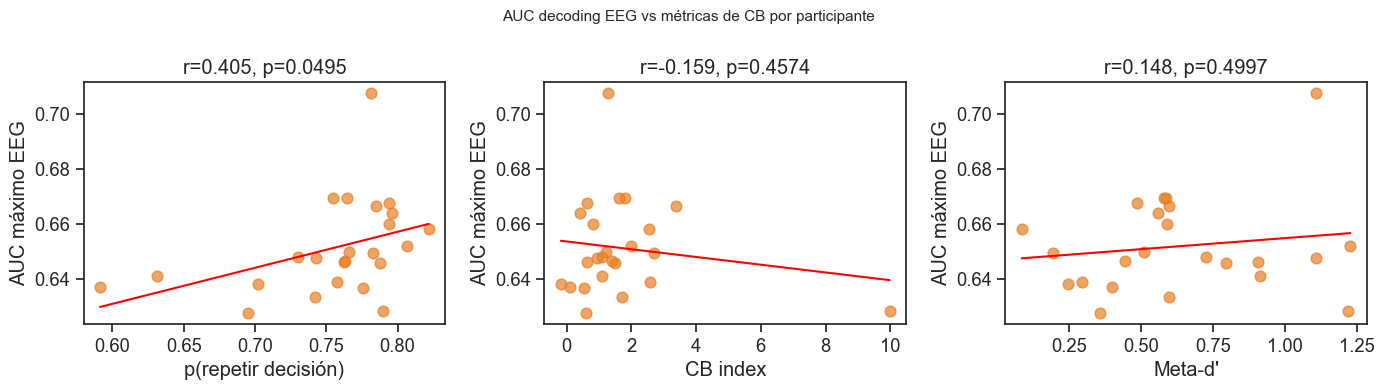

In [29]:
# ¿Los participantes con mayor decoding EEG tienen mayor CB?
# Si el CB se refleja en la señal cerebral, esperamos correlación
# entre el AUC del EEG y las métricas conductuales de CB

# Cargamos el summary conductual
summary = pd.read_csv('summary_behavioural.csv')

# Unimos con AUC EEG
merged_eeg = df_auc_resp.merge(
    summary[['subj', 'cbias_idx', 'p_repeat',
             'stuborness', 'metad', 'correct']],
    on='subj', how='inner'
)

print(f'Participantes con datos completos: {len(merged_eeg)}')
print('\nCorrelaciones AUC EEG ~ métricas conductuales:\n')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label in zip(
    axes,
    ['p_repeat', 'cbias_idx', 'metad'],
    ['p(repetir decisión)', 'CB index', 'Meta-d\'']
):
    if col not in merged_eeg.columns:
        continue
    datos = merged_eeg.dropna(subset=[col, 'auc_max'])
    r, p = stats.pearsonr(datos['auc_max'], datos[col])
    sig = '✓' if p < 0.05 else 'n.s.'
    print(f'AUC EEG ~ {col:15s}: r={r:.3f}, p={p:.4f} {sig}')

    ax.scatter(datos[col], datos['auc_max'],
               color='#e67e22', alpha=0.7, s=60)
    m, b = np.polyfit(datos[col].dropna(),
                      datos.loc[datos[col].notna(), 'auc_max'], 1)
    x_line = np.linspace(datos[col].min(), datos[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel('AUC máximo EEG')
    ax.set_title(f'r={r:.3f}, p={p:.4f}')

plt.suptitle('AUC decoding EEG vs métricas de CB por participante',
             fontsize=11)
plt.tight_layout()
plt.show()